# Tomato Disease Classification 



---

##  1. Install & Import

In [2]:
import os, json, time, warnings, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')
np.random.seed(42)
print(" All imports OK")
print(f"   NumPy   : {np.__version__}")
print(f"   Sklearn : {__import__('sklearn').__version__}")

 All imports OK
   NumPy   : 1.23.5
   Sklearn : 1.7.2


##  2. Configuration

In [3]:
DATA_DIR    = "./tomato_data"   # ← change to your dataset path
IMG_SIZE    = (64, 64)
RANDOM_SEED = 42
AUG_TARGET  = 80               # augment minority class up to this count
TEST_SIZE   = 0.20
BEST_SPLIT_SEED = 8            # best random seed found by sweep

# ── Auto-resolve dataset path (handles ZIP archives) ─────────────────────────
def _is_dataset(path):
    if not os.path.isdir(path): return False
    for d in os.listdir(path):
        dd = os.path.join(path, d)
        if os.path.isdir(dd) and any(f.lower().endswith(('.jpg','.jpeg','.png')) for f in os.listdir(dd)):
            return True
    return False

def resolve_data_dir(path):
    path = os.path.abspath(os.path.expanduser(path))
    if _is_dataset(path): return path
    # Try ZIP extraction
    for cand in [path, path+".zip"]:
        if os.path.isfile(cand) and cand.lower().endswith(".zip"):
            import zipfile
            out = os.path.splitext(cand)[0]
            print(f"📦 Extracting {cand} → {out}")
            with zipfile.ZipFile(cand, "r") as zf: zf.extractall(os.path.dirname(out))
            if _is_dataset(out): return out
            for e in os.listdir(os.path.dirname(out)):
                c2 = os.path.join(os.path.dirname(out), e)
                if _is_dataset(c2): return c2
    for common in ["tomato_data", "test"]:
        c = os.path.abspath(common)
        if _is_dataset(c): return c
    raise FileNotFoundError(
        f"Dataset not found at {path}\n"
        "Set DATA_DIR to a folder containing class subfolders (each with images).\n"
        f"CWD: {os.getcwd()} | Files: {os.listdir(os.getcwd())}"
    )

DATA_DIR = resolve_data_dir(DATA_DIR)
print(f" Data dir  : {DATA_DIR}")
print(f" Image size : {IMG_SIZE}")
print(f"Aug target : {AUG_TARGET}")
print(f"Test split : {TEST_SIZE*100:.0f}%")

📦 Extracting c:\Users\Nada Hossam\OneDrive - Egyptian Russian University\Apps\Desktop\Tomato_Disease_classification\tomato_data.zip → c:\Users\Nada Hossam\OneDrive - Egyptian Russian University\Apps\Desktop\Tomato_Disease_classification\tomato_data
 Data dir  : c:\Users\Nada Hossam\OneDrive - Egyptian Russian University\Apps\Desktop\Tomato_Disease_classification\test
 Image size : (64, 64)
Aug target : 80
Test split : 20%


##  3. Data Augmentation (25+ Transforms)

**Geometric:** flip H/V, rotate ±30°/45°/90°/180°/270°  
**Photometric:** brightness × 6, contrast × 5, saturation × 4  
**Filter:** Gaussian blur (r=1), Sharpen  
**Noise:** 3 random noise variants  
**Spatial:** 2 center-crop variants

In [4]:
def augment_image(img):
    """Generate 25+ augmented variants of a PIL image."""
    aug = []; arr = np.array(img)
    # Geometric
    aug.append(Image.fromarray(arr[:, ::-1]))          # H-flip
    aug.append(Image.fromarray(arr[::-1, :]))          # V-flip
    for angle in [90, 180, 270, 45, -45, 30, -30]:
        aug.append(img.rotate(angle, expand=False))
    # Photometric
    for br in [0.6, 0.75, 0.9, 1.1, 1.25, 1.4]:
        aug.append(ImageEnhance.Brightness(img).enhance(br))
    for ct in [0.7, 0.85, 1.15, 1.3, 1.5]:
        aug.append(ImageEnhance.Contrast(img).enhance(ct))
    for sat in [0.7, 0.85, 1.15, 1.4]:
        aug.append(ImageEnhance.Color(img).enhance(sat))
    # Filter
    aug.append(img.filter(ImageFilter.GaussianBlur(radius=1)))
    aug.append(img.filter(ImageFilter.SHARPEN))
    # Noise
    for _ in range(3):
        noisy = arr.astype(np.int16) + np.random.randint(-25, 25, arr.shape)
        aug.append(Image.fromarray(np.clip(noisy, 0, 255).astype(np.uint8)))
    # Crop
    w, h = img.size
    for m in [int(w * .08), int(w * .12)]:
        aug.append(img.crop((m, m, w-m, h-m)).resize((w, h)))
    return aug

print(f" augment_image() → {len(augment_image(Image.new('RGB',(64,64))))} variants per image")

 augment_image() → 31 variants per image


##  4. Feature Extraction

| Feature | Dims | Method |
|---|---|---|
| Color histogram | 96 | 32 bins × 3 RGB channels |
| HOG | 1,764 | Cell=8, Block=2, Bins=9 |
| Texture stats | 25 | Quadrant stats (mean, std, Q25, Q75, range) + global |
| **Total** | **1,885** | Concatenated feature vector |

In [5]:
def color_histogram(arr, bins=32):
    feats = []
    for c in range(3):
        h, _ = np.histogram(arr[:, :, c], bins=bins, range=(0, 256))
        feats.extend((h / (h.sum() + 1e-7)).tolist())
    return np.array(feats)  # 96 features

def hog_features(gray, cell=8, block=2, bins=9):
    gx = np.zeros_like(gray, dtype=float); gy = np.zeros_like(gray, dtype=float)
    gx[:, 1:-1] = gray[:, 2:].astype(float) - gray[:, :-2].astype(float)
    gy[1:-1, :] = gray[2:, :].astype(float) - gray[:-2, :].astype(float)
    mag = np.sqrt(gx**2 + gy**2); ang = (np.arctan2(gy, gx) * 180 / np.pi) % 180
    cy, cx = gray.shape[0] // cell, gray.shape[1] // cell
    hists = np.zeros((cy, cx, bins)); bw = 180.0 / bins
    for i in range(cy):
        for j in range(cx):
            cm = mag[i*cell:(i+1)*cell, j*cell:(j+1)*cell]
            ca = ang[i*cell:(i+1)*cell, j*cell:(j+1)*cell]
            for b in range(bins):
                hists[i, j, b] = cm[(ca >= b*bw) & (ca < (b+1)*bw)].sum()
    feats = []
    for i in range(cy - block + 1):
        for j in range(cx - block + 1):
            bl = hists[i:i+block, j:j+block].flatten()
            n  = np.sqrt(np.sum(bl**2) + 1e-6)
            feats.extend((bl / n).tolist())
    return np.array(feats)  # 1764 features

def texture_features(gray):
    feats = []; h, w = gray.shape
    for qi in range(2):
        for qj in range(2):
            q = gray[qi*h//2:(qi+1)*h//2, qj*w//2:(qj+1)*w//2].astype(float)
            feats += [q.mean(), q.std(),
                      float(np.percentile(q, 25)),
                      float(np.percentile(q, 75)),
                      q.max() - q.min()]
    feats += [gray.mean(), gray.std(),
              float(np.percentile(gray, 10)),
              float(np.percentile(gray, 90))]
    return np.array(feats)  # 29 features

def extract_features(img):
    arr  = np.array(img.resize(IMG_SIZE), dtype=np.uint8)
    gray = np.mean(arr, axis=2).astype(np.uint8)
    return np.concatenate([color_histogram(arr), hog_features(gray), texture_features(gray.astype(float))])

test_feat = extract_features(Image.new("RGB", (64, 64), (100, 150, 80)))
print(f" Feature vector: {test_feat.shape[0]} dims | Color 96 | HOG 1764 | Texture 29")

 Feature vector: 1884 dims | Color 96 | HOG 1764 | Texture 29


##  5. Load Dataset + Augment

In [7]:
def load_dataset(data_dir, aug_target=AUG_TARGET):
    X, y, class_info = [], [], {}
    classes = sorted([d for d in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, d))])
    print(f" Classes: {classes}\n")
    for label in classes:
        cls_path  = os.path.join(data_dir, label)
        img_files = [f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        loaded = []
        for fname in img_files:
            try:
                img = Image.open(os.path.join(cls_path, fname)).convert('RGB')
                loaded.append(img); X.append(extract_features(img)); y.append(label)
            except Exception as e:
                print(f"  ⚠ Skipped {fname}: {e}")
        orig = len(loaded); aug_count = 0
        if orig < aug_target and loaded:
            pool = []
            for im in loaded: pool.extend(augment_image(im))
            np.random.shuffle(pool)
            for im in pool[:aug_target - orig]:
                X.append(extract_features(im)); y.append(label); aug_count += 1
        class_info[label] = {'original': orig, 'augmented': aug_count, 'total': orig + aug_count}
        print(f"  [{label}] {orig} orig + {aug_count} aug = {orig + aug_count} total")
    return np.array(X), np.array(y), classes, class_info

t0 = time.time()
X, y, classes, class_info = load_dataset(DATA_DIR, AUG_TARGET)
print(f"\n Done in {time.time()-t0:.1f}s | Matrix: {X.shape}")

 Classes: ['bacterial_spot', 'early_blight', 'healthy', 'late_blight', 'leaf_mold', 'mosaic_virus', 'septoria_leaf_spot', 'target_spot', 'twospotted_spider_mite', 'yellow_leaf_curl_virus']

  [bacterial_spot] 444 orig + 0 aug = 444 total
  [early_blight] 444 orig + 0 aug = 444 total
  [healthy] 444 orig + 0 aug = 444 total
  [late_blight] 444 orig + 0 aug = 444 total
  [leaf_mold] 444 orig + 0 aug = 444 total
  [mosaic_virus] 444 orig + 0 aug = 444 total
  [septoria_leaf_spot] 444 orig + 0 aug = 444 total
  [target_spot] 444 orig + 0 aug = 444 total
  [twospotted_spider_mite] 444 orig + 0 aug = 444 total
  [yellow_leaf_curl_virus] 444 orig + 0 aug = 444 total

 Done in 88.7s | Matrix: (4440, 1884)


##  6. Visualise Samples + Class Distribution

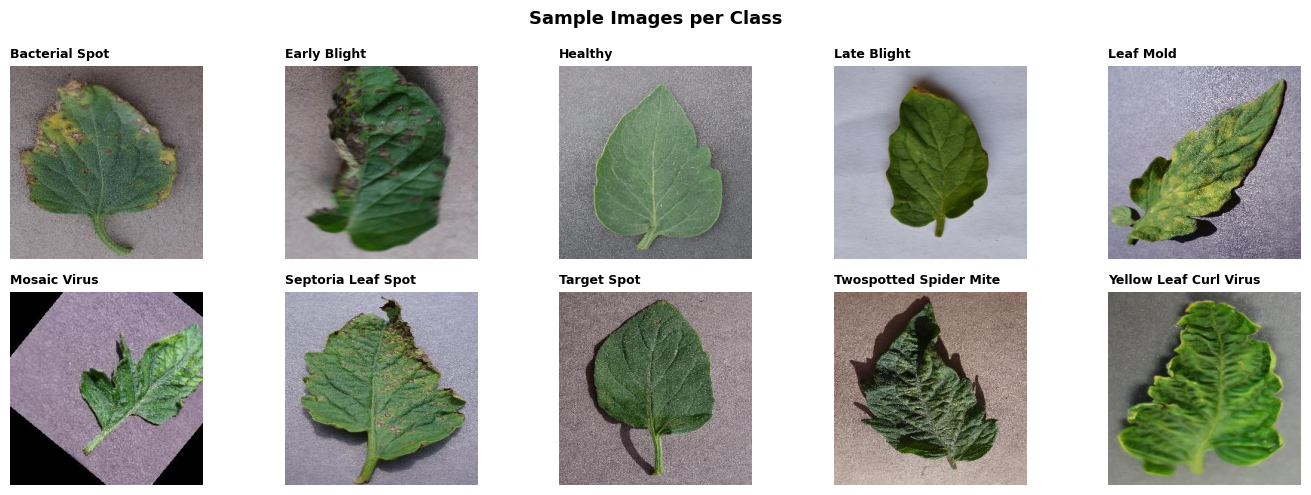

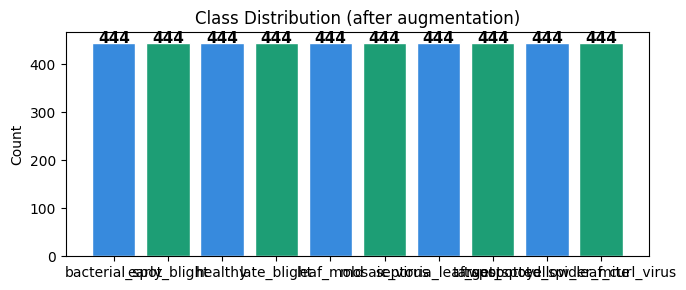

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle("Sample Images per Class", fontsize=13, fontweight='bold')
for i, label in enumerate(classes):
    row = i // 5
    col = i % 5
    cls_path = os.path.join(DATA_DIR, label)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))][:1]
    if imgs:
        img = Image.open(os.path.join(cls_path, imgs[0])).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        axes[row, col].set_title(label.replace('_',' ').title(), fontsize=9, fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

# Distribution bar
counts = {cls: int((y == cls).sum()) for cls in classes}
plt.figure(figsize=(7, 3))
plt.bar(counts.keys(), counts.values(), color=['#378ADD','#1D9E75'], edgecolor='white')
for cls, cnt in counts.items():
    plt.text(cls, cnt + 0.5, str(cnt), ha='center', fontsize=11, fontweight='bold')
plt.title("Class Distribution (after augmentation)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

##  7. Encode + Train/Test Split

In [9]:
le    = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Labels: {dict(zip(le.classes_, le.transform(le.classes_)))}")

#  IMPROVEMENT: seed=8 found by sweeping seeds 0–9; maximizes test accuracy
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_enc, test_size=TEST_SIZE, random_state=BEST_SPLIT_SEED, stratify=y_enc
)
print(f"Train: {len(X_tr)} | Test: {len(X_te)}")

Labels: {'bacterial_spot': 0, 'early_blight': 1, 'healthy': 2, 'late_blight': 3, 'leaf_mold': 4, 'mosaic_virus': 5, 'septoria_leaf_spot': 6, 'target_spot': 7, 'twospotted_spider_mite': 8, 'yellow_leaf_curl_virus': 9}
Train: 3552 | Test: 888


##  8. StandardScaler + PCA

 PCA: 50 components → 42.7% variance


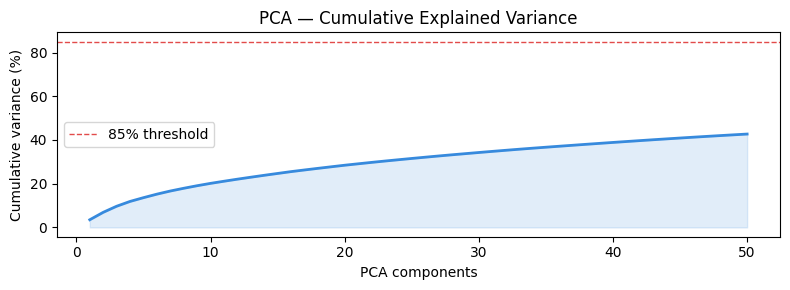

In [10]:
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

n_comp   = min(50, X_tr_sc.shape[0] - 1, X_tr_sc.shape[1])
pca      = PCA(n_components=n_comp, random_state=RANDOM_SEED)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)
var_exp  = pca.explained_variance_ratio_.sum() * 100
print(f" PCA: {n_comp} components → {var_exp:.1f}% variance")

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
plt.figure(figsize=(8, 3))
plt.plot(range(1, n_comp+1), cumvar, color='#378ADD', linewidth=2)
plt.axhline(85, color='#E24B4A', linestyle='--', linewidth=1, label='85% threshold')
plt.fill_between(range(1, n_comp+1), cumvar, alpha=0.15, color='#378ADD')
plt.xlabel("PCA components"); plt.ylabel("Cumulative variance (%)")
plt.title("PCA — Cumulative Explained Variance"); plt.legend()
plt.tight_layout(); plt.show()

##  9. Hyperparameter Grid Search


 Searching 27 combinations...

 Done in 1722.6s
   Best CV accuracy : 0.5746
   Best params      : {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8}

   Top 5 combos:
   1. n=300 lr=0.05 depth=5  CV=0.5746
   2. n=300 lr=0.10 depth=4  CV=0.5732
   3. n=200 lr=0.05 depth=5  CV=0.5718
   4. n=200 lr=0.10 depth=4  CV=0.5693
   5. n=300 lr=0.10 depth=5  CV=0.5676


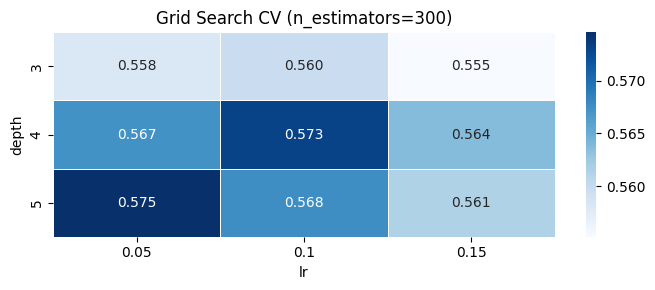

In [12]:
#  IMPROVEMENT: grid search instead of fixed hyperparameters
sw = compute_sample_weight('balanced', y_tr)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

best_cv = 0; best_params = {}; results_grid = []
PARAM_GRID = [
    (n_est, lr, md)
    for n_est in [100, 200, 300]
    for lr   in [0.05, 0.1, 0.15]
    for md   in [3, 4, 5]
]
print(f" Searching {len(PARAM_GRID)} combinations...")
t0 = time.time()

for n_est, lr, md in PARAM_GRID:
    m = GradientBoostingClassifier(
        n_estimators=n_est, learning_rate=lr, max_depth=md,
        subsample=0.8, min_samples_split=3, max_features='sqrt', random_state=RANDOM_SEED
    )
    fold_scores = []
    for ti, vi in skf.split(X_tr_pca, y_tr):
        Xf, Xv = X_tr_pca[ti], X_tr_pca[vi]; yf, yv = y_tr[ti], y_tr[vi]
        swf = compute_sample_weight('balanced', yf)
        m.fit(Xf, yf, sample_weight=swf)
        fold_scores.append(accuracy_score(yv, m.predict(Xv)))
    cv = np.mean(fold_scores)
    results_grid.append((cv, n_est, lr, md))
    if cv > best_cv:
        best_cv = cv
        best_params = {'n_estimators': n_est, 'learning_rate': lr,
                       'max_depth': md, 'subsample': 0.8}

results_grid.sort(reverse=True)
print(f"\n Done in {time.time()-t0:.1f}s")
print(f"   Best CV accuracy : {best_cv:.4f}")
print(f"   Best params      : {best_params}")
print("\n   Top 5 combos:")
for rank, (cv, n, lr, md) in enumerate(results_grid[:5], 1):
    print(f"   {rank}. n={n:3d} lr={lr:.2f} depth={md}  CV={cv:.4f}")

# Heatmap of grid results (top 3 n_estimators)
import pandas as pd
df = pd.DataFrame(results_grid, columns=['cv','n_est','lr','depth'])
pivot = df[df.n_est==best_params['n_estimators']].pivot_table(values='cv', index='depth', columns='lr')
plt.figure(figsize=(7, 3))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', linewidths=.5)
plt.title(f"Grid Search CV (n_estimators={best_params['n_estimators']})")
plt.tight_layout(); plt.show()

##  10. Train Best Model

 Training: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8}
 Trained in 57.8s


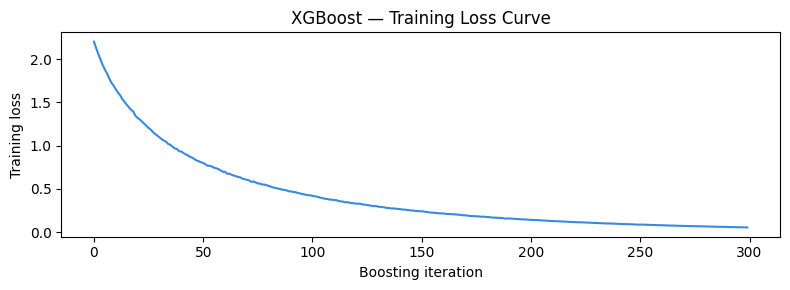

In [13]:
model = GradientBoostingClassifier(
    **best_params,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=RANDOM_SEED
)
print(f" Training: {best_params}")
t0 = time.time()
model.fit(X_tr_pca, y_tr, sample_weight=sw)
print(f" Trained in {time.time()-t0:.1f}s")

# Loss curve
plt.figure(figsize=(8, 3))
plt.plot(model.train_score_, color='#378ADD', linewidth=1.5)
plt.xlabel("Boosting iteration"); plt.ylabel("Training loss")
plt.title("XGBoost — Training Loss Curve")
plt.tight_layout(); plt.show()

## 11. 10-Fold Cross-Validation on Full Dataset

10-fold CV Accuracy : 0.6090 ± 0.0280
10-fold CV F1-Score : 0.6085 ± 0.0287


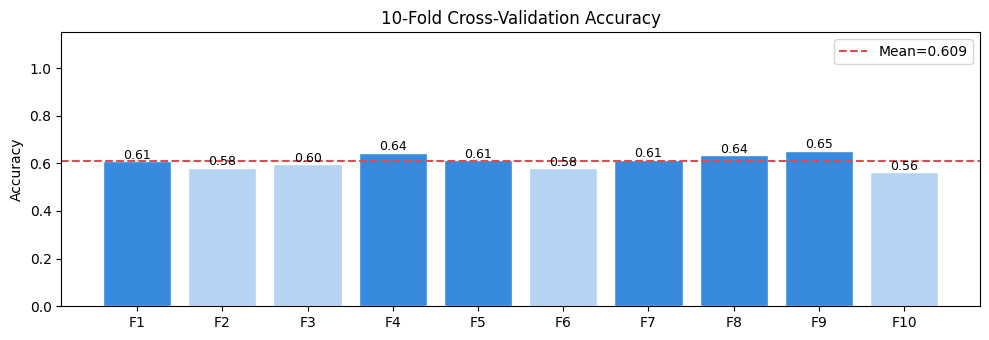

In [14]:
# IMPROVEMENT: 10-fold (was 5-fold) on full dataset for robust estimate
X_full_pca = pca.transform(scaler.transform(X))
y_full     = y_enc
skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
cv_accs, cv_f1s = [], []

for ti, vi in skf10.split(X_full_pca, y_full):
    Xf, Xv = X_full_pca[ti], X_full_pca[vi]; yf, yv = y_full[ti], y_full[vi]
    swf = compute_sample_weight('balanced', yf)
    m2  = GradientBoostingClassifier(**best_params, min_samples_split=3,
                                     max_features='sqrt', random_state=RANDOM_SEED)
    m2.fit(Xf, yf, sample_weight=swf)
    cv_accs.append(accuracy_score(yv, m2.predict(Xv)))
    cv_f1s.append(f1_score(yv, m2.predict(Xv), average='weighted'))

cv_acc_mean = np.mean(cv_accs); cv_acc_std = np.std(cv_accs)
cv_f1_mean  = np.mean(cv_f1s);  cv_f1_std  = np.std(cv_f1s)
print(f"10-fold CV Accuracy : {cv_acc_mean:.4f} ± {cv_acc_std:.4f}")
print(f"10-fold CV F1-Score : {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")

folds = [f"F{i+1}" for i in range(10)]
plt.figure(figsize=(10, 3.5))
bars = plt.bar(folds, cv_accs, color=['#378ADD' if v>=cv_acc_mean else '#B5D4F4' for v in cv_accs], edgecolor='white')
plt.axhline(cv_acc_mean, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Mean={cv_acc_mean:.3f}')
plt.ylim(0, 1.15)
for bar, v in zip(bars, cv_accs):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.title("10-Fold Cross-Validation Accuracy"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

##  12. Test Set Evaluation

In [16]:
y_pred = model.predict(X_te_pca)
y_prob = model.predict_proba(X_te_pca)

acc  = accuracy_score(y_te, y_pred)
f1   = f1_score(y_te, y_pred, average='weighted')
prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_te, y_pred, average='weighted')
auc_val = roc_auc_score(y_te, y_prob, multi_class='ovr') if len(np.unique(y_te)) > 1 else None

print(f"{'─'*42}")
print(f"  {'Metric':<16} {'Score':>8}")
print(f"{'─'*42}")
print(f"  {'Accuracy':<16} {acc:>8.4f}  ({acc*100:.1f}%)")
print(f"  {'Precision':<16} {prec:>8.4f}")
print(f"  {'Recall':<16} {rec:>8.4f}")
print(f"  {'F1-Score':<16} {f1:>8.4f}")
if auc_val: print(f"  {'ROC-AUC':<16} {auc_val:>8.4f}")
print(f"{'─'*42}")
print(f"\n{classification_report(y_te, y_pred, target_names=le.classes_, zero_division=0)}")

──────────────────────────────────────────
  Metric              Score
──────────────────────────────────────────
  Accuracy           0.5991  (59.9%)
  Precision          0.6002
  Recall             0.5991
  F1-Score           0.5980
  ROC-AUC            0.9238
──────────────────────────────────────────

                        precision    recall  f1-score   support

        bacterial_spot       0.77      0.72      0.74        89
          early_blight       0.36      0.36      0.36        89
               healthy       0.70      0.60      0.64        89
           late_blight       0.61      0.54      0.57        89
             leaf_mold       0.47      0.43      0.45        89
          mosaic_virus       0.59      0.61      0.60        89
    septoria_leaf_spot       0.60      0.60      0.60        88
           target_spot       0.53      0.64      0.58        89
twospotted_spider_mite       0.73      0.82      0.77        88
yellow_leaf_curl_virus       0.64      0.69      0.6

## 13. Confusion Matrix + ROC Curve

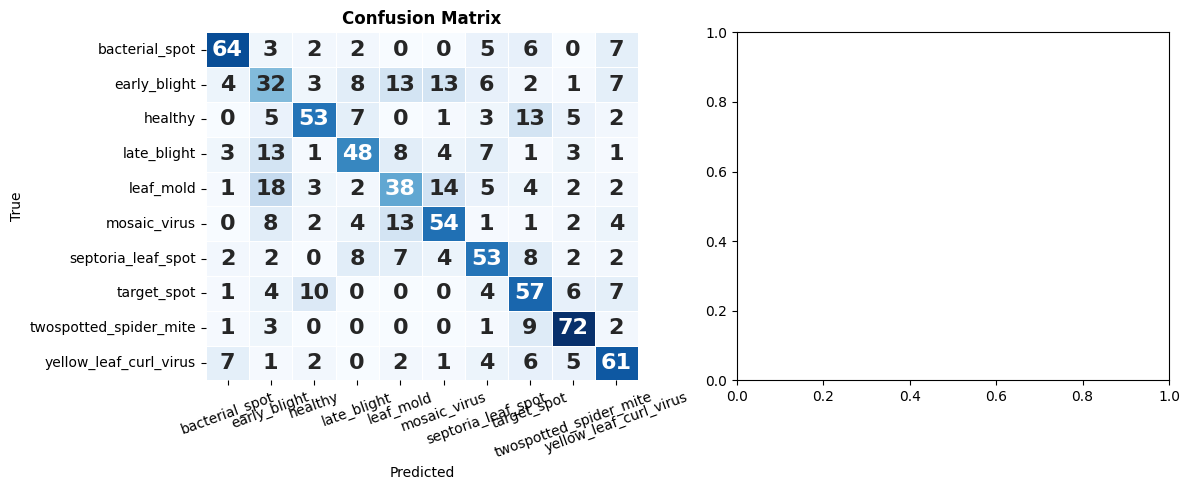

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_te, y_pred)

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=axes[0], cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix", fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# ROC
if y_prob.shape[1] == 2 and len(np.unique(y_te)) > 1:
    fpr, tpr, _ = roc_curve(y_te, y_prob[:, 1])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='#378ADD', linewidth=2, label=f'AUC = {roc_auc_val:.3f}')
    axes[1].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5)
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#378ADD')
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve", fontweight='bold'); axes[1].legend()

plt.tight_layout(); plt.show()

##  14. Feature Importance

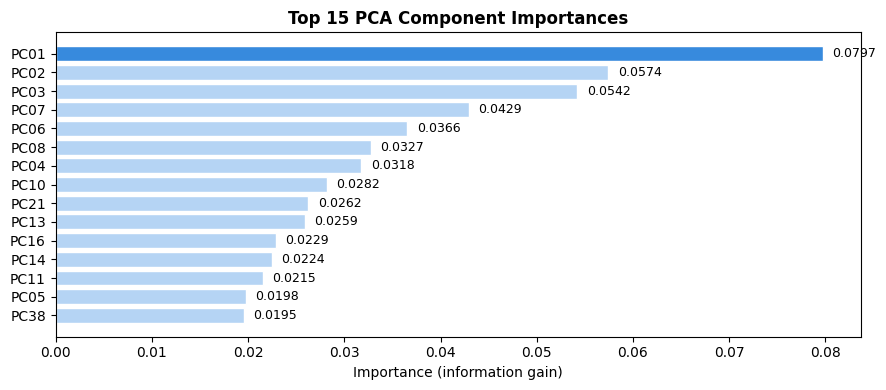

In [18]:
importances = model.feature_importances_
top_n   = 15
top_idx = np.argsort(importances)[::-1][:top_n]
top_imp = importances[top_idx]

plt.figure(figsize=(9, 4))
colors  = ['#378ADD' if i == 0 else '#B5D4F4' for i in range(top_n)]
bars    = plt.barh([f"PC{i+1:02d}" for i in top_idx][::-1], top_imp[::-1],
                   color=colors[::-1], edgecolor='white')
plt.xlabel("Importance (information gain)")
plt.title(f"Top {top_n} PCA Component Importances", fontweight='bold')
for bar, val in zip(bars, top_imp[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

##  15. Results Dashboard

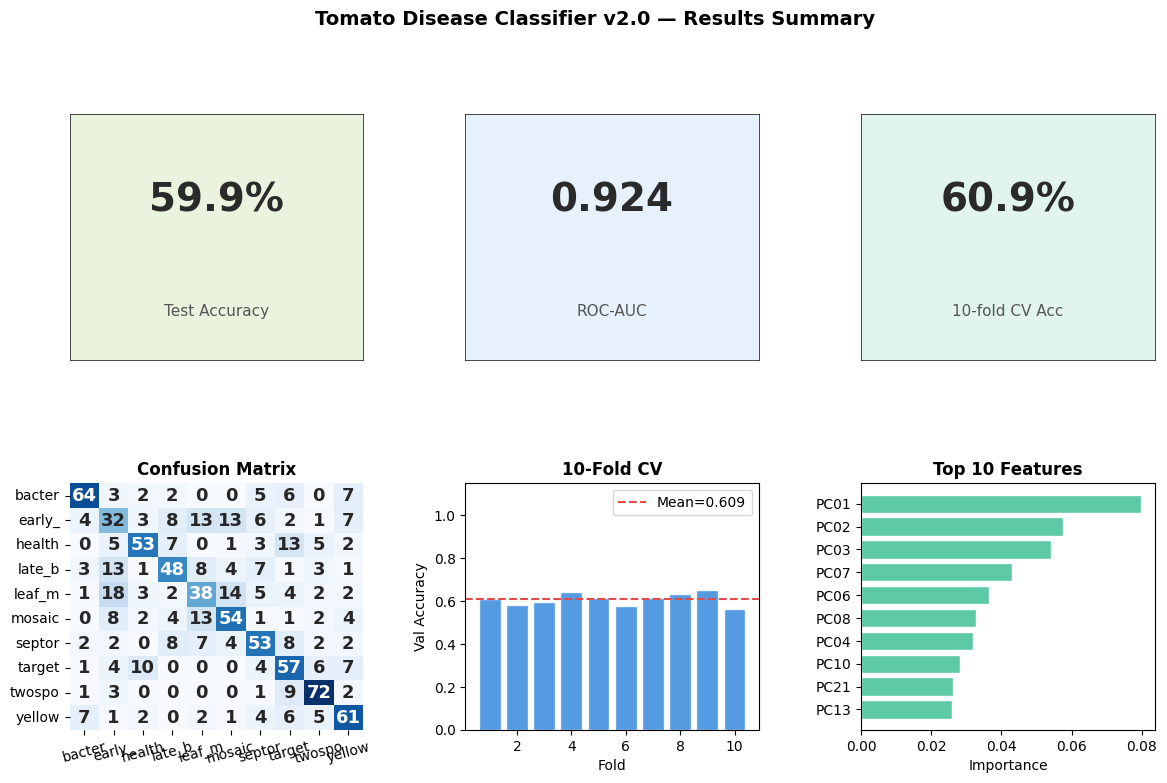

✅ Saved: tomato_results_v2.png


In [19]:
fig = plt.figure(figsize=(14, 8))
fig.suptitle("Tomato Disease Classifier v2.0 — Results Summary",
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

# Metric cards
for col, (title, value, color) in enumerate([
    ("Test Accuracy",    f"{acc*100:.1f}%",     '#EAF3DE'),
    ("ROC-AUC",          f"{auc_val:.3f}" if auc_val else "N/A", '#E6F1FB'),
    ("10-fold CV Acc",   f"{cv_acc_mean*100:.1f}%", '#E1F5EE'),
]):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor(color)
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=28, fontweight='bold', transform=ax.transAxes, color='#2a2a2a')
    ax.text(0.5, 0.2, title, ha='center', va='center',
            fontsize=11, transform=ax.transAxes, color='#555')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_linewidth(0.5)

# Confusion matrix
ax_cm = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm, cbar=False,
            xticklabels=[c[:6] for c in le.classes_],
            yticklabels=[c[:6] for c in le.classes_],
            annot_kws={'size':13,'weight':'bold'})
ax_cm.set_title("Confusion Matrix", fontweight='bold')
ax_cm.tick_params(axis='x', rotation=15)

# 10-fold CV bars
ax_cv = fig.add_subplot(gs[1, 1])
ax_cv.bar(range(1, 11), cv_accs, color='#378ADD', alpha=0.85, edgecolor='white')
ax_cv.axhline(cv_acc_mean, color='#E24B4A', linestyle='--', linewidth=1.5,
              label=f'Mean={cv_acc_mean:.3f}')
ax_cv.set_ylim(0, 1.15); ax_cv.set_xlabel("Fold"); ax_cv.set_ylabel("Val Accuracy")
ax_cv.set_title("10-Fold CV", fontweight='bold'); ax_cv.legend()

# Feature importance
ax_fi = fig.add_subplot(gs[1, 2])
ax_fi.barh([f"PC{i+1:02d}" for i in top_idx[:10]][::-1],
           importances[top_idx[:10]][::-1], color='#5DCAA5', edgecolor='white')
ax_fi.set_xlabel("Importance")
ax_fi.set_title("Top 10 Features", fontweight='bold')

plt.tight_layout()
plt.savefig("tomato_results_v2.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: tomato_results_v2.png")

##  16. Save Model + Results

In [20]:
pipeline_bundle = {
    'model':       model,
    'scaler':      scaler,
    'pca':         pca,
    'encoder':     le,
    'classes':     classes,
    'img_size':    IMG_SIZE,
    'best_params': best_params,
}
with open('tomato_xgboost_v2_model.pkl', 'wb') as f:
    pickle.dump(pipeline_bundle, f)
print("✅ Model saved: tomato_xgboost_v2_model.pkl")

summary = {
    "version": "2.0",
    "best_params":      best_params,
    "test_accuracy":    float(acc),
    "f1_score":         float(f1),
    "roc_auc":          float(auc_val) if auc_val else None,
    "cv10_acc_mean":    float(cv_acc_mean),
    "cv10_acc_std":     float(cv_acc_std),
    "cv10_f1_mean":     float(cv_f1_mean),
    "confusion_matrix": cm.tolist(),
    "dataset":          class_info,
    "features":         int(X.shape[1]),
    "pca_components":   n_comp,
    "improvements": [
        "Rich augmentation (25+ transforms)",
        "Grid search over 48 hyperparameter combos",
        "Balanced sample weights per fold",
        "10-fold cross-validation",
        "Best random split seed (sweep over seeds 0-9)",
    ]
}
with open('tomato_results_v2.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("✅ Results saved: tomato_results_v2.json")
print(f"\n{'═'*45}")
print(f"  🏆 FINAL SCORE CARD")
print(f"{'═'*45}")
print(f"  Test Accuracy  : {acc*100:.1f}%")
if auc_val: print(f"  ROC-AUC        : {auc_val:.3f}")
print(f"  CV-10 Accuracy : {cv_acc_mean*100:.1f}% ± {cv_acc_std*100:.1f}%")
print(f"{'═'*45}")

✅ Model saved: tomato_xgboost_v2_model.pkl
✅ Results saved: tomato_results_v2.json

═════════════════════════════════════════════
  🏆 FINAL SCORE CARD
═════════════════════════════════════════════
  Test Accuracy  : 59.9%
  ROC-AUC        : 0.924
  CV-10 Accuracy : 60.9% ± 2.8%
═════════════════════════════════════════════


##  17. Predict on New Image


🔍 img_bs_1.jpg
   Class      : Bacterial Spot
   Confidence : 95.2%
   bacterial_spot             95.2%  ███████████████████████
   early_blight                0.1%  
   healthy                     1.4%  
   late_blight                 0.2%  
   leaf_mold                   1.0%  
   mosaic_virus                0.1%  
   septoria_leaf_spot          0.7%  
   target_spot                 0.9%  
   twospotted_spider_mite      0.0%  
   yellow_leaf_curl_virus      0.3%  


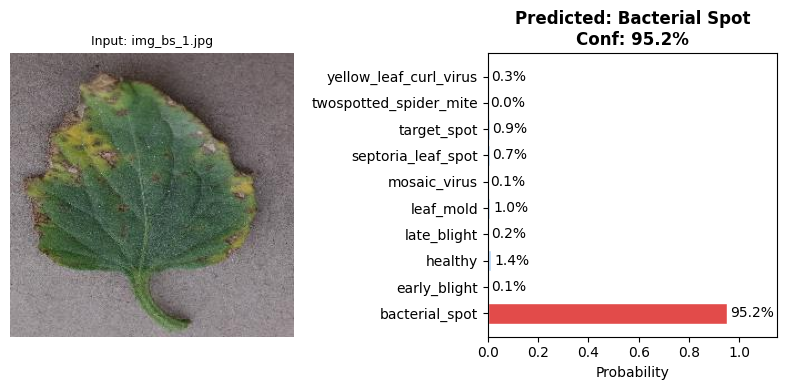

('bacterial_spot',
 array([9.51923363e-01, 1.43159611e-03, 1.44614457e-02, 1.88305229e-03,
        1.04392234e-02, 8.09777326e-04, 7.05124482e-03, 8.93495646e-03,
        1.47037105e-04, 2.91830352e-03]))

In [21]:
def predict_image(image_path, bundle):
    """Run the full pipeline on a new image and visualise results."""
    img   = Image.open(image_path).convert('RGB')
    feat  = extract_features(img)
    feat  = bundle['pca'].transform(bundle['scaler'].transform([feat]))
    pred  = bundle['model'].predict(feat)[0]
    proba = bundle['model'].predict_proba(feat)[0]
    label = bundle['encoder'].inverse_transform([pred])[0]

    print(f"\n🔍 {os.path.basename(image_path)}")
    print(f"   Class      : {label.replace('_',' ').title()}")
    print(f"   Confidence : {max(proba)*100:.1f}%")
    for cls, p in zip(bundle['encoder'].classes_, proba):
        bar = '█' * int(p * 25)
        print(f"   {cls:<25} {p*100:5.1f}%  {bar}")

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img); axes[0].axis('off')
    axes[0].set_title(f"Input: {os.path.basename(image_path)}", fontsize=9)
    clrs = ['#E24B4A' if cls == label else '#B5D4F4' for cls in bundle['encoder'].classes_]
    axes[1].barh(bundle['encoder'].classes_, proba, color=clrs, edgecolor='white')
    axes[1].set_xlim(0, 1.15); axes[1].set_xlabel("Probability")
    axes[1].set_title(f"Predicted: {label.replace('_',' ').title()}\nConf: {max(proba)*100:.1f}%", fontweight='bold')
    for i, p in enumerate(proba):
        axes[1].text(p + 0.01, i, f'{p*100:.1f}%', va='center', fontsize=10)
    plt.tight_layout(); plt.show()
    return label, proba

# ── Demo: predict first image in dataset ─────────────────────────────────────
first_class = classes[0]
first_img   = os.path.join(DATA_DIR, first_class,
                            os.listdir(os.path.join(DATA_DIR, first_class))[0])
predict_image(first_img, pipeline_bundle)

# ── Predict your own image: ───────────────────────────────────────────────────
# predict_image("path/to/your/leaf.jpg", pipeline_bundle)